# Prostate cancer detection with MobileNetV2.


## Imports


In [1]:
from collections import Counter
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
from IPython.display import display
from PIL import Image
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, make_scorer, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from tensorflow.keras.applications import MobileNetV2


I0000 00:00:1790115717.548870    3135 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790115717.549790    3135 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790115728.415382    3135 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790115742.853445    3135 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Configuration and data loading


In [2]:
DATA_DIR = Path.cwd()
IMAGE_DIR = DATA_DIR / "images"
MASK_DIR = DATA_DIR / "masks"
FEATURE_DIR = DATA_DIR / "extracted_features"
MODEL_DIR = DATA_DIR / "model_artifacts"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
RANDOM_STATE = 42
MIN_MEAN_SENSITIVITY = 0.90
GRADE_COLUMNS = ["NC", "G3", "G4", "G5"]
CLASS_NAMES = ["Non-cancerous", "Cancerous"]
METRIC_COLUMNS = [
    "Accuracy", "Precision", "Sensitivity", "Specificity",
    "Balanced Accuracy", "F1 Score", "ROC-AUC",
]

train_df = pd.read_excel(DATA_DIR / "partition" / "Test" / "Train.xlsx")
test_df = pd.read_excel(DATA_DIR / "partition" / "Test" / "Test.xlsx")
wsi_df = pd.read_excel(DATA_DIR / "wsi_labels.xlsx")
display(train_df.head(), wsi_df.head())


,image_name,NC,G3,G4,G5,G4C
0,16B0001851_Block_Region_1_0_0_xini_6803_yini_5...,0,0,0,1,0
1,16B0001851_Block_Region_1_0_1_xini_7827_yini_5...,0,0,0,1,0
2,16B0001851_Block_Region_1_0_2_xini_8851_yini_5...,0,0,0,1,0
3,16B0001851_Block_Region_1_0_3_xini_9875_yini_5...,0,0,0,1,0
4,16B0001851_Block_Region_1_1_0_xini_6803_yini_6...,0,0,0,1,0


,slide_id,patient_id,Gleason_primary,Gleason_secondary
0,16B0001851,667360,4,5
1,16B0003388,325687,4,4
2,16B0003394,747184,3,3
3,16B0006668,14107,5,5
4,16B0006669,14107,5,5


## Reusable utilities


In [3]:
def prepare_labels(df, patient_lookup):
    df = df.copy()
    assert df["image_name"].notna().all(), "Missing image names."
    assert df["image_name"].is_unique, "Duplicate image names."
    assert df[GRADE_COLUMNS].isin([0, 1]).all().all(), "Invalid grade labels."
    assert df[GRADE_COLUMNS].sum(axis=1).eq(1).all(), "Expected one grade per patch."
    df["cancer"] = (1 - df["NC"]).astype("int32")
    df["slide_id"] = df["image_name"].str.split("_Block_", n=1).str[0]
    df["patient_id"] = df["slide_id"].map(patient_lookup)
    assert df["patient_id"].notna().all(), "Missing patient IDs."
    return df


def check_separation(left, right):
    assert set(left["image_name"]).isdisjoint(right["image_name"]), "Shared images."
    assert set(left["patient_id"]).isdisjoint(right["patient_id"]), "Shared patients."


def binary_metrics(y, predictions, scores=None):
    tn, fp, fn, tp = confusion_matrix(y, predictions, labels=[0, 1]).ravel()
    sensitivity = recall_score(y, predictions, zero_division=0)
    specificity = tn / (tn + fp) if tn + fp else np.nan
    result = {
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions, zero_division=0),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Balanced Accuracy": (sensitivity + specificity) / 2,
        "F1 Score": f1_score(y, predictions, zero_division=0),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }
    if scores is not None:
        result["ROC-AUC"] = (
            roc_auc_score(y, scores) if len(np.unique(y)) == 2 else np.nan
        )
    return result


def evaluate_model(model, X, y, threshold=None):
    if hasattr(model, "predict_proba"):
        positive_index = list(model.classes_).index(1)
        scores = model.predict_proba(X)[:, positive_index]
    else:
        if threshold is not None:
            raise ValueError("Probability thresholds require predict_proba.")
        scores = model.decision_function(X)
    predictions = (
        model.predict(X) if threshold is None
        else (scores >= threshold).astype(int)
    )
    return binary_metrics(y, predictions, scores), predictions, scores


def summarize_metrics(results, group=None):
    if group is not None:
        return results.groupby(group)[METRIC_COLUMNS].agg(["mean", "std"])
    return results[METRIC_COLUMNS].agg(["mean", "std"]).T


def show_classification(y, predictions, title, save_path=None):
    report = classification_report(
        y, predictions, labels=[0, 1], target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    display(pd.DataFrame(report).T.round(4))
    chart = ConfusionMatrixDisplay.from_predictions(
        y, predictions, labels=[0, 1], display_labels=CLASS_NAMES,
        cmap="Greens", values_format="d",
    )
    chart.ax_.set_title(title)
    chart.figure_.tight_layout()
    if save_path is not None:
        chart.figure_.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return report


def load_image(path, label):
    image = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, tf.cast(label, tf.int32)


def make_dataset(df):
    paths = [str(image_files[name]) for name in df["image_name"]]
    labels = df["cancer"].to_numpy(dtype="int32")
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


def extract_features(df, extractor, save_path):
    features = extractor.predict(make_dataset(df), verbose=1)
    labels = df["cancer"].to_numpy(dtype="int32")
    names = df["image_name"].to_numpy(dtype=str)
    assert features.shape == (len(df), 1280)
    assert np.isfinite(features).all(), "Non-finite CNN features."
    save_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(save_path, features=features, labels=labels, image_names=names)
    return features, labels, names


def convert_numpy_value(value):
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Cannot serialize {type(value).__name__}")


scoring_metrics = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "sensitivity": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}


## Data inspection and integrity checks


In [4]:
wsi_lookup = wsi_df.copy()
wsi_lookup["slide_id"] = wsi_lookup["slide_id"].astype(str)
assert wsi_lookup["slide_id"].is_unique, "Duplicate slide metadata."
patient_lookup = wsi_lookup.set_index("slide_id")["patient_id"]
train_df = prepare_labels(train_df, patient_lookup)
test_df = prepare_labels(test_df, patient_lookup)
check_separation(train_df, test_df)

image_paths = [path for path in IMAGE_DIR.rglob("*") if path.is_file()]
image_files = {path.name: path for path in image_paths}
assert len(image_files) == len(image_paths), "Duplicate image basenames."
mask_paths = list(MASK_DIR.rglob("*.png"))
mask_files = {path.stem: path for path in mask_paths}
assert len(mask_files) == len(mask_paths), "Duplicate mask stems."
labelled_df = pd.concat([train_df, test_df], ignore_index=True)
assert labelled_df["image_name"].isin(image_files).all(), "Missing patch images."
missing_masks = labelled_df.loc[
    ~labelled_df["image_name"].map(lambda name: Path(name).stem in mask_files),
    "image_name",
]
assert missing_masks.empty, "Missing annotation masks for inspection."

inspection_rows = []
for name, df in [("Development", train_df), ("Final test", test_df)]:
    inspection_rows.append({
        "Set": name, "Patches": len(df), "Patients": df["patient_id"].nunique(),
        "Non-cancerous": int((df["cancer"] == 0).sum()),
        "Cancerous": int((df["cancer"] == 1).sum()),
        **df[GRADE_COLUMNS].sum().to_dict(),
    })
display(pd.DataFrame(inspection_rows).set_index("Set"))


,Patches,Patients,Non-cancerous,Cancerous,NC,G3,G4,G5
Set,,,,,,,,
Development,9959,74,3773,6186,3773,1829,3641,716
Final test,2122,21,644,1478,644,393,853,232


## Exploratory image and mask analysis

Masks are inspected as annotations


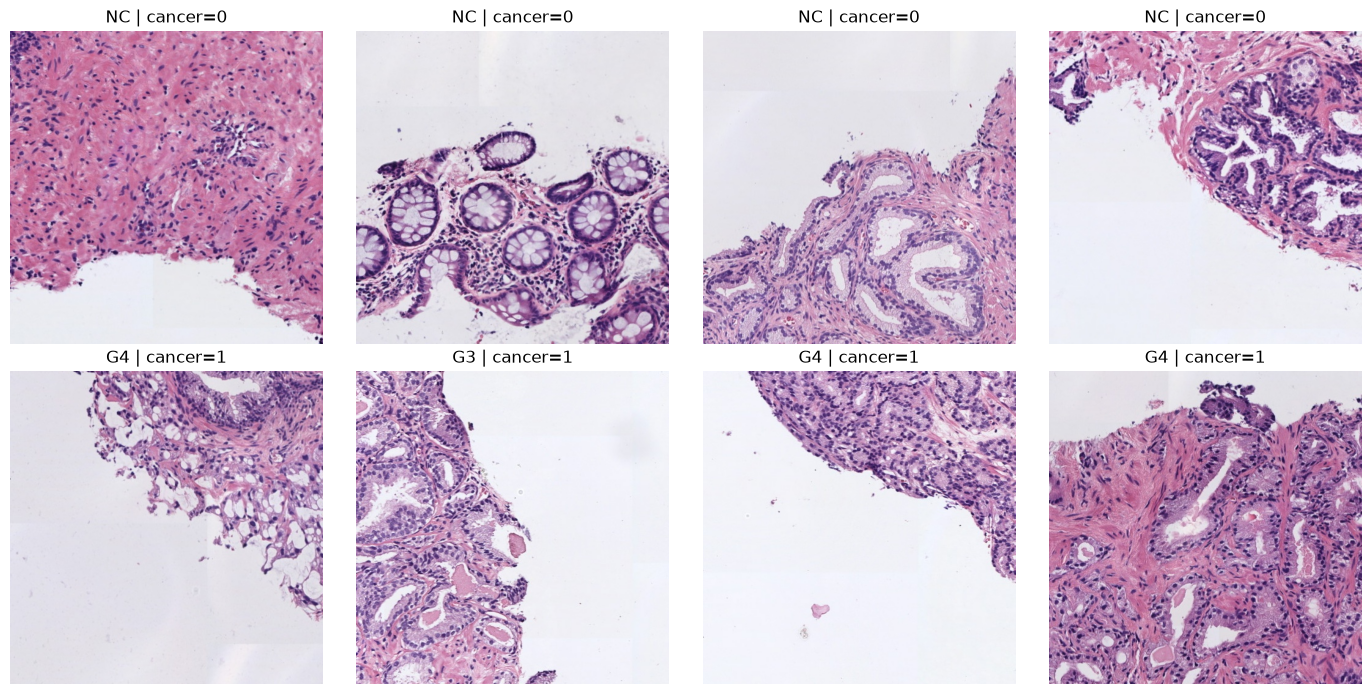

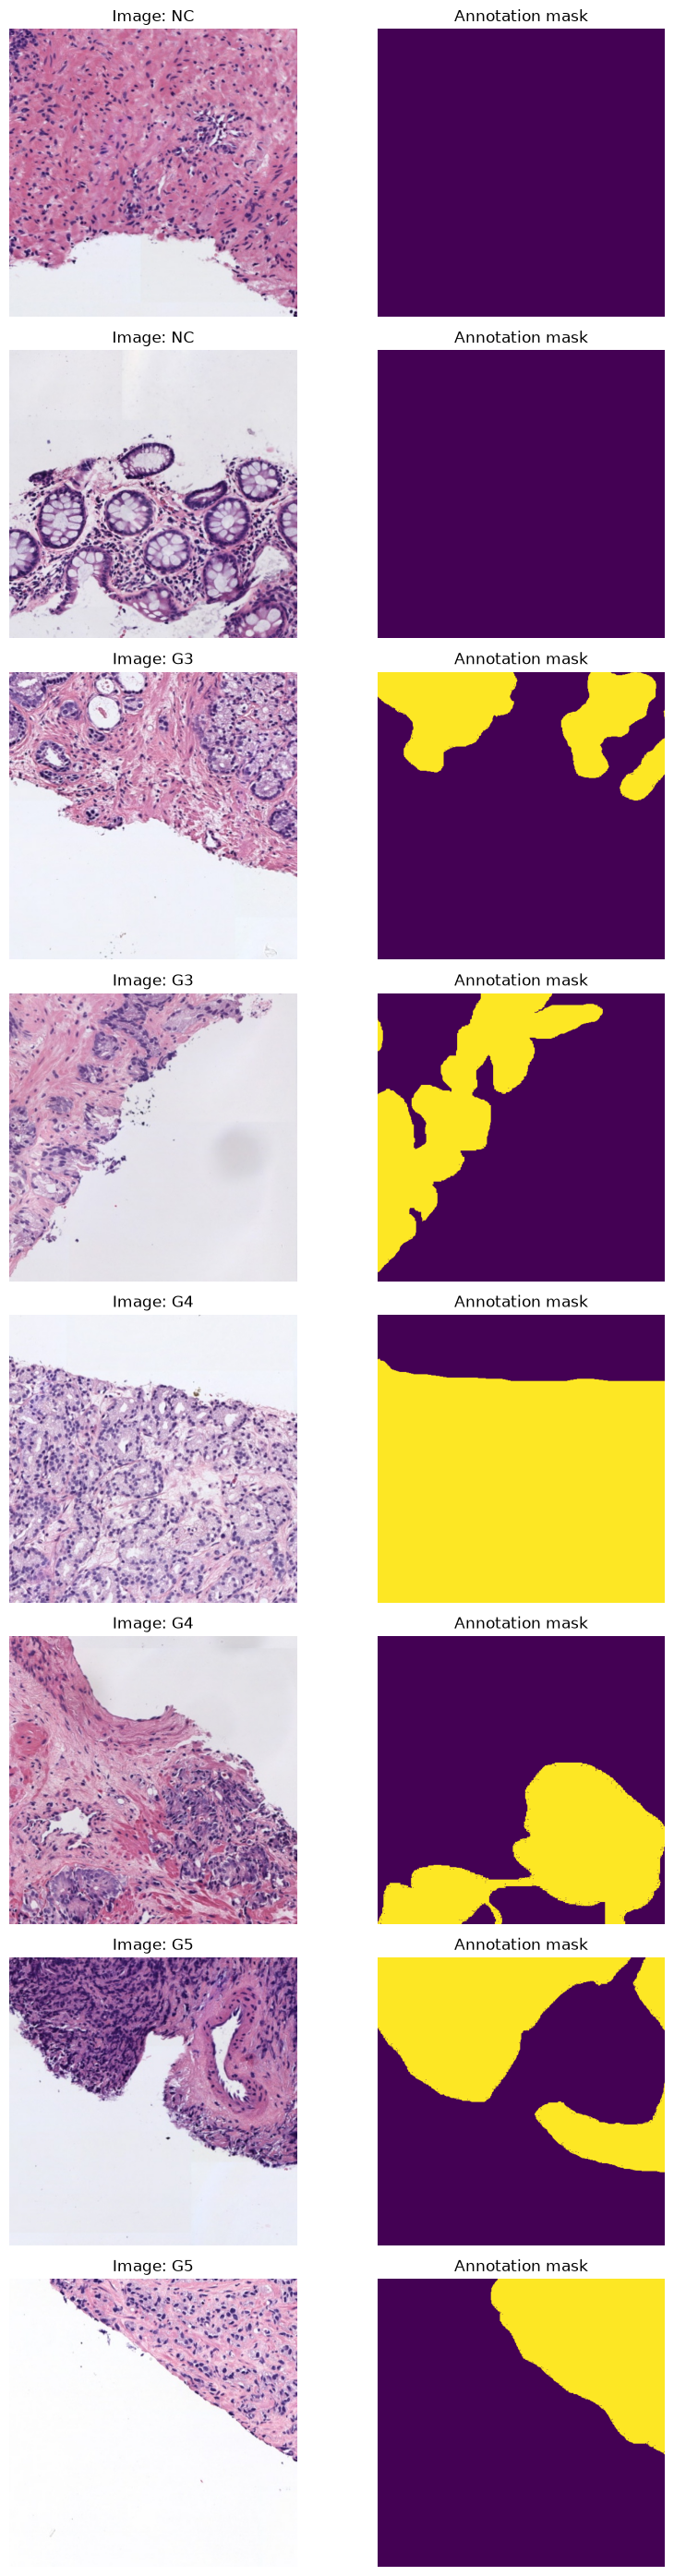

0    2464269683
3     190692549
4     428112074
5      83887358
Name: Mask pixel count, dtype: int64

In [5]:
samples = pd.concat(
    [
        train_df.loc[train_df["cancer"] == 0].sample(4, random_state=RANDOM_STATE),
        train_df.loc[train_df["cancer"] == 1].sample(4, random_state=RANDOM_STATE),
    ]
)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    with Image.open(image_files[row["image_name"]]) as image:
        ax.imshow(image.convert("RGB"))

    grade = next(col for col in ["NC", "G3", "G4", "G5"] if row[col] == 1)
    ax.set_title(f"{grade} | cancer={row['cancer']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

samples = pd.concat(
    [
        train_df.loc[train_df[grade] == 1].sample(2, random_state=RANDOM_STATE)
        for grade in ["NC", "G3", "G4", "G5"]
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(len(samples), 2, figsize=(9, 28))

for i, row in samples.iterrows():
    name = row["image_name"]
    grade = next(col for col in ["NC", "G3", "G4", "G5"] if row[col] == 1)

    with Image.open(image_files[name]) as image:
        image_array = np.asarray(image.convert("RGB"))

    with Image.open(mask_files[Path(name).stem]) as mask:
        mask_array = np.asarray(mask)


    axes[i, 0].imshow(image_array)
    axes[i, 0].set_title(f"Image: {grade}")
    axes[i, 1].imshow(mask_array, cmap="viridis", vmin=0, vmax=3)
    axes[i, 1].set_title("Annotation mask")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.show()

mask_value_counts = Counter()
for name in labelled_df["image_name"]:
    with Image.open(mask_files[Path(name).stem]) as mask:
        values, counts = np.unique(np.asarray(mask), return_counts=True)
    mask_value_counts.update({int(v): int(n) for v, n in zip(values, counts)})
display(pd.Series(dict(sorted(mask_value_counts.items())), name="Mask pixel count"))


## Patient-based validation folds


In [6]:
feature_index = pd.Series(np.arange(len(train_df)), index=train_df["image_name"])
cv_splits = []
fold_rows = []
validation_coverage = np.zeros(len(train_df), dtype=int)

for fold_number in range(1, 5):
    fold_dir = DATA_DIR / "partition" / "Validation" / f"Val{fold_number}"
    fold_train_df = prepare_labels(pd.read_excel(fold_dir / "Train.xlsx"), patient_lookup)
    fold_valid_df = prepare_labels(pd.read_excel(fold_dir / "Test.xlsx"), patient_lookup)
    check_separation(fold_train_df, fold_valid_df)
    assert (set(fold_train_df["image_name"]) | set(fold_valid_df["image_name"])) == set(train_df["image_name"])
    train_indices = feature_index.loc[fold_train_df["image_name"]].to_numpy()
    valid_indices = feature_index.loc[fold_valid_df["image_name"]].to_numpy()
    for df, indices in [(fold_train_df, train_indices), (fold_valid_df, valid_indices)]:
        assert np.array_equal(df["cancer"].to_numpy(), train_df.iloc[indices]["cancer"].to_numpy())
    cv_splits.append((train_indices, valid_indices))
    validation_coverage[valid_indices] += 1
    fold_rows.append({
        "Fold": fold_number, "Training patches": len(train_indices),
        "Validation patches": len(valid_indices),
        "Training patients": fold_train_df["patient_id"].nunique(),
        "Validation patients": fold_valid_df["patient_id"].nunique(),
    })

assert np.all(validation_coverage == 1), "Each patch must be validated exactly once."
display(pd.DataFrame(fold_rows))


,Fold,Training patches,Validation patches,Training patients,Validation patients
0,1,7472,2487,56,18
1,2,7793,2166,57,17
2,3,8166,1793,55,19
3,4,6446,3513,54,20


## CNN feature extraction

Feature extraction preserves image order and uses the original frozen ImageNet MobileNetV2 and batch size of 8.


In [7]:
cnn_feature_extractor = MobileNetV2(
    weights="imagenet", include_top=False,
    input_shape=(*IMAGE_SIZE, 3), pooling="avg",
)
cnn_feature_extractor.trainable = False
assert not cnn_feature_extractor.trainable_weights

X_development, y_development, development_names = extract_features(
    train_df, cnn_feature_extractor,
    FEATURE_DIR / "mobilenetv2_development_features.npz",
)
display(pd.DataFrame({"Patches": [len(y_development)], "Features": [X_development.shape[1]]}))


E0000 00:00:1790115850.915008    3135 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1245/1245 ━━━━━━━━━━━━━━━━━━━━ 360s 287ms/step


,Patches,Features
0,9959,1280


## Baseline models and four-fold validation

Val1 results and plots come from the first fold, avoiding a duplicate training run.


,precision,recall,f1-score,support
Non-cancerous,0.5983,0.7197,0.6534,685.0000
Cancerous,0.8845,0.8163,0.8491,1802.0000
accuracy,0.7897,0.7897,0.7897,0.7897
macro avg,0.7414,0.7680,0.7512,2487.0000
weighted avg,0.8057,0.7897,0.7952,2487.0000


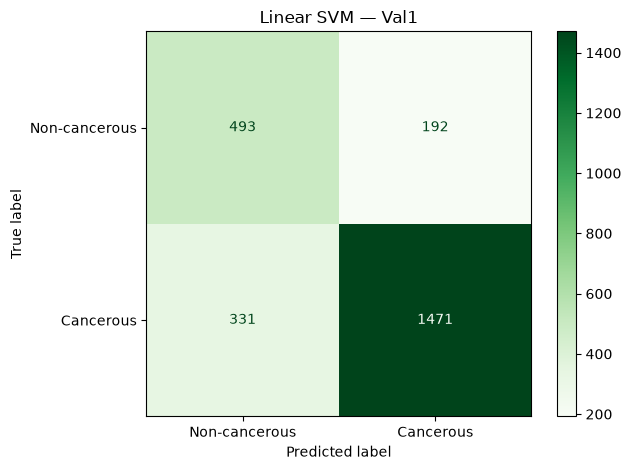

,precision,recall,f1-score,support
Non-cancerous,0.6797,0.6073,0.6415,685.000
Cancerous,0.8565,0.8912,0.8735,1802.000
accuracy,0.8130,0.8130,0.8130,0.813
macro avg,0.7681,0.7493,0.7575,2487.000
weighted avg,0.8078,0.8130,0.8096,2487.000


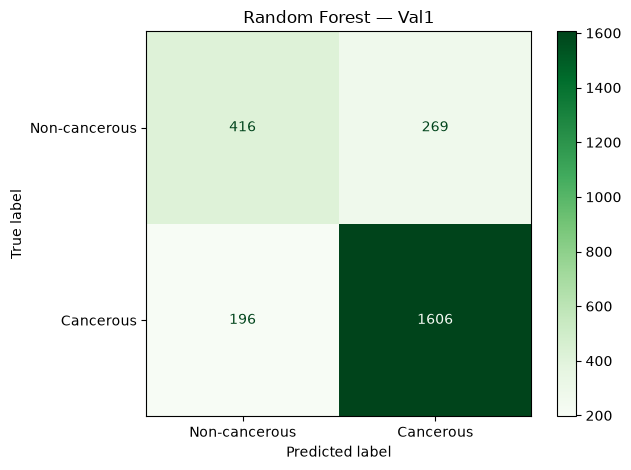

,precision,recall,f1-score,support
Non-cancerous,0.6071,0.4964,0.5462,685.0000
Cancerous,0.8210,0.8779,0.8485,1802.0000
accuracy,0.7728,0.7728,0.7728,0.7728
macro avg,0.7141,0.6871,0.6973,2487.0000
weighted avg,0.7621,0.7728,0.7652,2487.0000


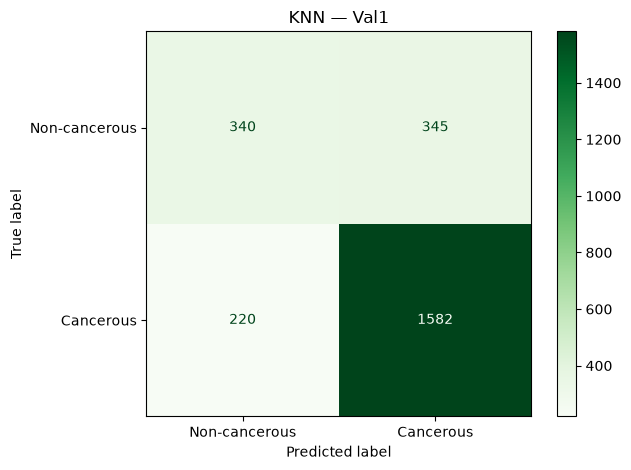

,Fold,Model,Accuracy,Precision,Sensitivity,Specificity,Balanced Accuracy,F1 Score,ROC-AUC
0,1,Linear SVM,0.7897,0.8845,0.8163,0.7197,0.7680,0.8491,0.8579
1,1,Random Forest,0.8130,0.8565,0.8912,0.6073,0.7493,0.8735,0.8811
2,1,KNN,0.7728,0.8210,0.8779,0.4964,0.6871,0.8485,0.8190
3,2,Linear SVM,0.7922,0.8014,0.9165,0.5411,0.7288,0.8551,0.8632
4,2,Random Forest,0.8246,0.8339,0.9213,0.6290,0.7752,0.8754,0.9125
5,2,KNN,0.7793,0.7874,0.9179,0.4993,0.7086,0.8477,0.8417
6,3,Linear SVM,0.7440,0.8048,0.7929,0.6568,0.7248,0.7988,0.8066
7,3,Random Forest,0.7646,0.7982,0.8468,0.6180,0.7324,0.8218,0.8411
8,3,KNN,0.7407,0.7631,0.8634,0.5217,0.6925,0.8101,0.7878
9,4,Linear SVM,0.6365,0.5970,0.8768,0.3880,0.6324,0.7104,0.7482


,Model,Accuracy,Precision,Sensitivity,Specificity,Balanced Accuracy,F1 Score,ROC-AUC
0,KNN,0.7339 ± 0.0631,0.7415 ± 0.1008,0.8983 ± 0.0331,0.4648 ± 0.0829,0.6815 ± 0.0305,0.8082 ± 0.0573,0.8026 ± 0.0350
1,Linear SVM,0.7406 ± 0.0729,0.7719 ± 0.1228,0.8506 ± 0.0564,0.5764 ± 0.1458,0.7135 ± 0.0575,0.8033 ± 0.0669,0.8190 ± 0.0537
2,Random Forest,0.7585 ± 0.0883,0.7681 ± 0.1252,0.9053 ± 0.0486,0.5362 ± 0.1640,0.7208 ± 0.0654,0.8243 ± 0.0697,0.8726 ± 0.0313


In [8]:
base_models = {
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            metric="euclidean",
            algorithm="brute",
            n_jobs=-1,
        )),
    ]),
}

validation_results = []
val1_reports = {}
for fold_number, (train_indices, valid_indices) in enumerate(cv_splits, start=1):
    for model_name, base_model in base_models.items():
        started = time.time()
        model = clone(base_model)
        model.fit(X_development[train_indices], y_development[train_indices])
        metrics, predictions, scores = evaluate_model(
            model, X_development[valid_indices], y_development[valid_indices],
        )
        validation_results.append({
            "Fold": fold_number, "Model": model_name, **metrics,
            "Runtime Seconds": time.time() - started,
        })
        if fold_number == 1:
            val1_reports[model_name] = show_classification(
                y_development[valid_indices], predictions, f"{model_name} — Val1",
            )

validation_results_df = pd.DataFrame(validation_results)
val1_results = validation_results_df.loc[validation_results_df["Fold"] == 1]
cross_validation_summary = summarize_metrics(validation_results_df, "Model")
final_validation_summary = pd.DataFrame({
    metric: cross_validation_summary[(metric, "mean")].map("{:.4f}".format)
    + " ± " + cross_validation_summary[(metric, "std")].map("{:.4f}".format)
    for metric in METRIC_COLUMNS
}).reset_index()
display(validation_results_df[["Fold", "Model"] + METRIC_COLUMNS].round(4))
display(final_validation_summary)


Random Forest preform better than the other model based on evaluation metrics especially sensitivity(recall), so i are choosing random forest as the final model 

## Random Forest hyperparameter search



In [9]:
rf_search_model = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


rf_parameter_distributions = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 20, 30],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_samples": [0.7, 0.85, None],
}


rf_random_search = RandomizedSearchCV(
    estimator=rf_search_model,
    param_distributions=rf_parameter_distributions,
    n_iter=10,
    scoring=scoring_metrics,
    refit="roc_auc",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)



rf_random_search.fit(X_development, y_development)
rf_search_results = pd.DataFrame(rf_random_search.cv_results_)
result_columns = [
    "rank_test_roc_auc", "mean_test_roc_auc", "std_test_roc_auc",
    "mean_test_accuracy", "mean_test_balanced_accuracy",
    "mean_test_precision", "mean_test_sensitivity", "mean_test_f1", "params",
]
display(rf_search_results[result_columns].sort_values("rank_test_roc_auc").round(4))
display(pd.Series(rf_random_search.best_params_, name="Selected value"))


Fitting 4 folds for each of 10 candidates, totalling 40 fits


,rank_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_precision,mean_test_sensitivity,mean_test_f1,params
9,1,0.8731,0.0264,0.7607,0.7224,0.7691,0.9070,0.8258,"{'n_estimators': 300, 'min_samples_split': 5, ..."
4,2,0.8719,0.0277,0.7592,0.7204,0.7678,0.9053,0.8244,"{'n_estimators': 300, 'min_samples_split': 5, ..."
6,3,0.8719,0.0286,0.7551,0.7123,0.7607,0.9136,0.8236,"{'n_estimators': 300, 'min_samples_split': 5, ..."
7,4,0.8714,0.0284,0.7573,0.7187,0.7663,0.9063,0.8238,"{'n_estimators': 200, 'min_samples_split': 2, ..."
8,5,0.8711,0.0305,0.7670,0.7339,0.7797,0.8952,0.8275,"{'n_estimators': 400, 'min_samples_split': 5, ..."
1,6,0.8707,0.0295,0.7650,0.7322,0.7789,0.8938,0.8261,"{'n_estimators': 300, 'min_samples_split': 2, ..."
2,7,0.8704,0.0310,0.7679,0.7351,0.7809,0.8939,0.8277,"{'n_estimators': 400, 'min_samples_split': 10,..."
3,8,0.8698,0.0301,0.7613,0.7242,0.7711,0.9019,0.8251,"{'n_estimators': 300, 'min_samples_split': 10,..."
5,9,0.8686,0.0305,0.7548,0.7130,0.7612,0.9116,0.8230,"{'n_estimators': 200, 'min_samples_split': 10,..."
0,10,0.8682,0.0280,0.7604,0.7242,0.7714,0.8993,0.8241,"{'n_estimators': 200, 'min_samples_split': 10,..."


n_estimators          300
min_samples_split       5
min_samples_leaf        2
max_samples          None
max_features         sqrt
max_depth              20
Name: Selected value, dtype: object

## Optimized out-of-fold predictions

These development results reuse folds used for hyperparameter selection, so they are not an independent performance estimate.

In [10]:
oof_probabilities = np.full(len(y_development), np.nan)
oof_predictions = np.full(len(y_development), -1, dtype=int)
optimized_fold_results = []

for fold_number, (train_indices, valid_indices) in enumerate(cv_splits, start=1):
    fold_model = clone(rf_random_search.best_estimator_)
    fold_model.fit(X_development[train_indices], y_development[train_indices])
    metrics, predictions, scores = evaluate_model(
        fold_model, X_development[valid_indices], y_development[valid_indices],
        threshold=0.50,
    )
    oof_probabilities[valid_indices] = scores
    oof_predictions[valid_indices] = predictions
    optimized_fold_results.append({"Fold": fold_number, **metrics})

assert np.isfinite(oof_probabilities).all()
assert (oof_predictions >= 0).all()
optimized_fold_results_df = pd.DataFrame(optimized_fold_results)
optimized_summary = summarize_metrics(optimized_fold_results_df)
display(optimized_fold_results_df[["Fold"] + METRIC_COLUMNS].round(4))
display(optimized_summary.round(4))


,Fold,Accuracy,Precision,Sensitivity,Specificity,Balanced Accuracy,F1 Score,ROC-AUC
0,1,0.8154,0.8562,0.8957,0.6044,0.7500,0.8755,0.8825
1,2,0.8195,0.8282,0.9213,0.6137,0.7675,0.8723,0.9116
2,3,0.7697,0.8041,0.8468,0.6320,0.7394,0.8249,0.8437
3,4,0.6382,0.5879,0.9642,0.3011,0.6326,0.7304,0.8545


,mean,std
Accuracy,0.7607,0.0847
Precision,0.7691,0.1227
Sensitivity,0.9070,0.0491
Specificity,0.5378,0.1582
Balanced Accuracy,0.7224,0.0609
F1 Score,0.8258,0.0676
ROC-AUC,0.8731,0.0305


## Decision threshold selection



In [11]:
threshold_rows = []
threshold_metrics = [metric for metric in METRIC_COLUMNS if metric != "ROC-AUC"]
for threshold in np.round(np.arange(0.20, 0.81, 0.01), 2):
    fold_metrics = pd.DataFrame([
        binary_metrics(
            y_development[valid_indices],
            (oof_probabilities[valid_indices] >= threshold).astype(int),
        )
        for _, valid_indices in cv_splits
    ])
    threshold_rows.append({
        "Threshold": float(threshold),
        **fold_metrics[threshold_metrics].mean().to_dict(),
        "Minimum Fold Sensitivity": fold_metrics["Sensitivity"].min(),
    })

threshold_results_df = pd.DataFrame(threshold_rows)
eligible_thresholds = threshold_results_df.loc[
    threshold_results_df["Sensitivity"] >= MIN_MEAN_SENSITIVITY
].sort_values(["Balanced Accuracy", "Specificity"], ascending=False)
if eligible_thresholds.empty:
    raise ValueError("No tested threshold meets the development sensitivity requirement.")
best_threshold_row = eligible_thresholds.iloc[0]
selected_threshold = float(best_threshold_row["Threshold"])
FINAL_THRESHOLD = selected_threshold
comparison_thresholds = threshold_results_df.loc[
    np.isclose(threshold_results_df["Threshold"], 0.50)
    | np.isclose(threshold_results_df["Threshold"], selected_threshold)
].copy()
comparison_thresholds["Threshold Type"] = [
    "Default and selected" if np.isclose(t, 0.50) and np.isclose(t, selected_threshold)
    else "Default" if np.isclose(t, 0.50) else "Selected"
    for t in comparison_thresholds["Threshold"]
]
display(comparison_thresholds.round(4), eligible_thresholds.head(10).round(4))


,Threshold,Accuracy,Precision,Sensitivity,Specificity,Balanced Accuracy,F1 Score,Minimum Fold Sensitivity,Threshold Type
30,0.5,0.7607,0.7691,0.907,0.5378,0.7224,0.8258,0.8468,Default and selected


,Threshold,Accuracy,Precision,Sensitivity,Specificity,Balanced Accuracy,F1 Score,Minimum Fold Sensitivity
30,0.50,0.7607,0.7691,0.9070,0.5378,0.7224,0.8258,0.8468
29,0.49,0.7566,0.7622,0.9130,0.5158,0.7144,0.8243,0.8529
28,0.48,0.7505,0.7533,0.9199,0.4870,0.7035,0.8219,0.8607
27,0.47,0.7454,0.7454,0.9266,0.4601,0.6934,0.8199,0.8668
26,0.46,0.7406,0.7386,0.9320,0.4362,0.6841,0.8180,0.8729
25,0.45,0.7341,0.7306,0.9363,0.4090,0.6727,0.8149,0.8790
24,0.44,0.7268,0.7228,0.9402,0.3817,0.6609,0.8115,0.8842
23,0.43,0.7206,0.7157,0.9446,0.3556,0.6501,0.8088,0.8930
22,0.42,0.7148,0.7090,0.9492,0.3304,0.6398,0.8063,0.8999
21,0.41,0.7098,0.7031,0.9538,0.3073,0.6306,0.8044,0.9051


0.50 was chosen as the best threshold

## Final test evaluation



In [12]:
final_test_df = test_df.copy()
X_final_test, y_final_test, final_test_names = extract_features(
    final_test_df, cnn_feature_extractor,
    FEATURE_DIR / "mobilenetv2_final_test_features.npz",
)
final_rf_model = rf_random_search.best_estimator_
final_metrics, final_test_predictions, final_test_probabilities = evaluate_model(
    final_rf_model, X_final_test, y_final_test, threshold=FINAL_THRESHOLD,
)
final_test_results = pd.DataFrame({
    "Metric": METRIC_COLUMNS,
    "Score": [final_metrics[metric] for metric in METRIC_COLUMNS],
})
display(final_test_results.round(4))


266/266 ━━━━━━━━━━━━━━━━━━━━ 73s 271ms/step


,Metric,Score
0,Accuracy,0.8153
1,Precision,0.8684
2,Sensitivity,0.8660
3,Specificity,0.6988
4,Balanced Accuracy,0.7824
5,F1 Score,0.8672
6,ROC-AUC,0.8811


## Final evaluation plots


,precision,recall,f1-score,support
Non-cancerous,0.6944,0.6988,0.6966,644.0000
Cancerous,0.8684,0.8660,0.8672,1478.0000
accuracy,0.8153,0.8153,0.8153,0.8153
macro avg,0.7814,0.7824,0.7819,2122.0000
weighted avg,0.8156,0.8153,0.8154,2122.0000


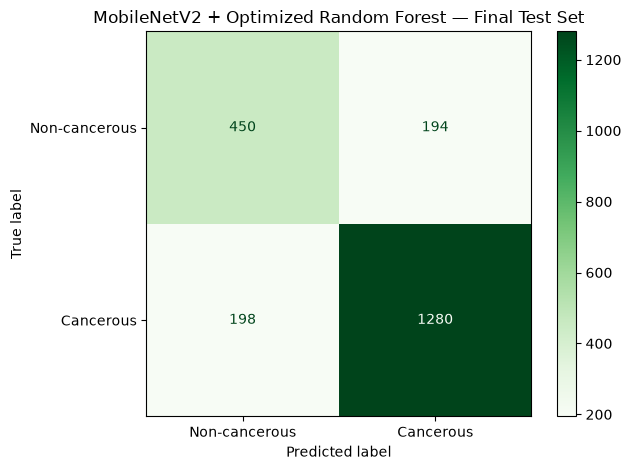

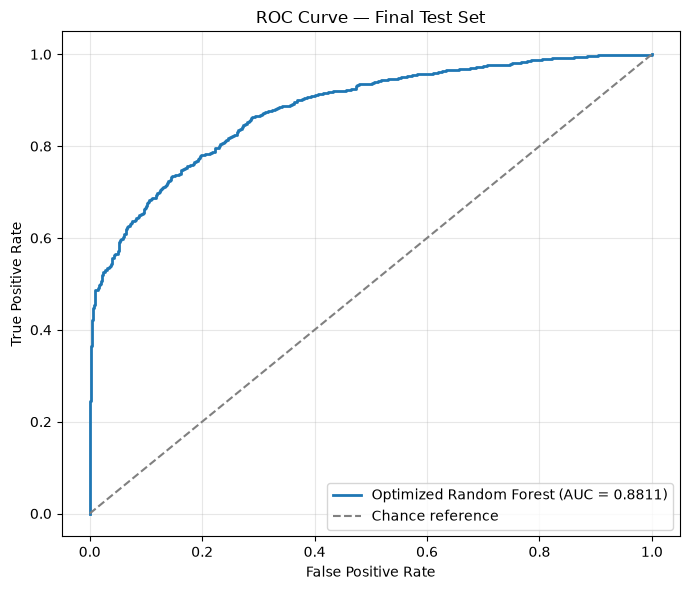

In [13]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
final_report = show_classification(
    y_final_test, final_test_predictions,
    "MobileNetV2 + Optimized Random Forest — Final Test Set",
    MODEL_DIR / "final_test_confusion_matrix.png",
)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_final_test, final_test_probabilities,
)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(false_positive_rate, true_positive_rate, linewidth=2,
        label=f"Optimized Random Forest (AUC = {final_metrics['ROC-AUC']:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance reference")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve — Final Test Set")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(MODEL_DIR / "final_test_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## Save models and results


In [ ]:
joblib.dump(final_rf_model, MODEL_DIR / "optimized_random_forest.joblib")
cnn_feature_extractor.save(MODEL_DIR / "mobilenetv2_feature_extractor.keras")
final_test_results.to_csv(MODEL_DIR / "final_test_metrics.csv", index=False)
final_predictions_df = pd.DataFrame({
    "image_name": final_test_names,
    "true_label": y_final_test,
    "predicted_label": final_test_predictions,
    "cancer_probability": final_test_probabilities,
})
final_predictions_df.to_csv(MODEL_DIR / "final_test_predictions.csv", index=False)
rf_search_results.to_csv(MODEL_DIR / "rf_search_results.csv", index=False)
np.savez_compressed(
    MODEL_DIR / "development_oof_predictions.npz",
    image_names=development_names, labels=y_development,
    probabilities=oof_probabilities, predictions=oof_predictions,
)
model_information = {
    "cnn_feature_extractor": "MobileNetV2",
    "cnn_weights": "ImageNet",
    "image_size": list(IMAGE_SIZE),
    "preprocessing": "RGB JPEG; tf.image.resize (bilinear); mobilenet_v2.preprocess_input",
    "feature_dimension": int(X_development.shape[1]),
    "classifier": "RandomForestClassifier",
    "classification_threshold": FINAL_THRESHOLD,
    "class_labels": {"0": "Non-cancerous", "1": "Cancerous"},
    "evaluation_unit": "image patch",
    "best_parameters": rf_random_search.best_params_,
    "classifier_parameters": final_rf_model.get_params(),
    "final_test_metrics": final_metrics,
    "versions": {"tensorflow": tf.__version__, "scikit-learn": sklearn.__version__,
                 "numpy": np.__version__, "pandas": pd.__version__},
}
with (MODEL_DIR / "model_information.json").open("w", encoding="utf-8") as file:
    json.dump(model_information, file, indent=4, default=convert_numpy_value)
print("model saved")


model saved
